# Emotion Rewrites Dataset — Statistics
Statistical overview of `emotion_rewrites.csv`/`emotion_rewrites.jsonl`: source/split distributions, intensity-level breakdown, meaning-preservation scores, rewrite length analysis, and vocabulary diversity across the 8 Plutchik emotion dimensions.

## 1. Import Required Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 2. Load and Preview the Dataset

In [13]:
DATA_PATH = "../../dataset/emotion_rewrites/emotion_rewrites.csv"

df = pd.read_csv(DATA_PATH)

EMOTION_COLS = [
    "joy_rewrite", "trust_rewrite", "fear_rewrite", "surprise_rewrite",
    "sadness_rewrite", "disgust_rewrite", "anger_rewrite", "anticipation_rewrite"
]
EMOTION_LABELS = [c.replace("_rewrite", "") for c in EMOTION_COLS]

print(f"Shape: {df.shape}")
df.head(3)

Shape: (68349, 14)


,source_dataset,source_split,source_id,intensity_level,base_text,meaning_preserved_score,joy_rewrite,trust_rewrite,fear_rewrite,surprise_rewrite,sadness_rewrite,disgust_rewrite,anger_rewrite,anticipation_rewrite
0,dailydialog,train,dd_train_9999_0,low,"Hi , Helen . Where are you going on this summe...",9.00,"Hi, Helen. Any plans for summer vacation? Disn...","Hi, Helen. Where are you headed for summer? Di...","Hi, Helen. Where are you going this summer? Di...","Hi, Helen. Summer plans? Disneyland? Didn't ex...","Hi, Helen. Where are you going this summer? Di...","Hi, Helen. So, summer plans? Disneyland. Not r...","Hi, Helen. Where are you off to this summer? D...","Hi, Helen. Where are you going this summer? Di..."
1,dailydialog,train,dd_train_9999_0,medium,"Hi , Helen . Where are you going on this summe...",0.95,"Hi, Helen. What’s your plan for this summer? D...","Hi, Helen. Where will you be heading this summ...","Hi, Helen. Where are you off to this summer? D...","Hi, Helen. Where’s the summer taking you? Disn...","Hi, Helen. Got any plans for summer? Disneylan...","Hi, Helen. What’s your summer destination? Dis...","Hi, Helen. Where are you going this summer? Di...","Hi, Helen. What are your summer vacation plans..."
2,dailydialog,train,dd_train_9999_0,high,"Hi , Helen . Where are you going on this summe...",0.95,"Wow, Disneyland this summer? That's amazing—I ...",Disneyland sounds like a solid choice. I’m sur...,"Disneyland, huh? I hope it's safe and not too ...","Wait, Disneyland? That’s unexpected! I didn’t ...",Disneyland again? I wish I could go somewhere ...,Disneyland? Really? That place is always so ch...,"Disneyland? Ugh, why would you go somewhere so...","Disneyland, huh? You must be counting down the..."


## 2a. Normalize `meaning_preserved_score` to [0, 1]\n\nThe column contains a mix of two scales: ~80% of rows use **0.0–1.0** directly, while the remaining ~20% appear to have been stored on a **0–10** scale. Rows where the raw value > 1.0 are divided by 10 to unify the range.

In [14]:
raw_over1 = (df["meaning_preserved_score"] > 1.0).sum()
print(f"Raw values > 1.0 (10-scale entries): {raw_over1:,} / {len(df):,} ({raw_over1/len(df):.1%})")

# Unify to 0–1 scale
df["meaning_preserved_score"] = df["meaning_preserved_score"].where(
    df["meaning_preserved_score"] <= 1.0,
    df["meaning_preserved_score"] / 10.0,
)

print("\nAfter normalization:")
print(df["meaning_preserved_score"].describe())
assert df["meaning_preserved_score"].between(0.0, 1.0).all(), "Still has out-of-range values!"
print("\nAll values are in [0.0, 1.0] ✓")

Raw values > 1.0 (10-scale entries): 13,819 / 68,349 (20.2%)

After normalization:
count    68349.000000
mean         0.943238
std          0.020740
min          0.400000
25%          0.950000
50%          0.950000
75%          0.950000
max          1.000000
Name: meaning_preserved_score, dtype: float64

All values are in [0.0, 1.0] ✓


## 3. Basic Info & Missing Values

In [15]:
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

source_dataset                 str
source_split                   str
source_id                      str
intensity_level                str
base_text                      str
meaning_preserved_score    float64
joy_rewrite                    str
trust_rewrite                  str
fear_rewrite                   str
surprise_rewrite               str
sadness_rewrite                str
disgust_rewrite                str
anger_rewrite                  str
anticipation_rewrite           str
dtype: object

Null counts:
source_dataset             0
source_split               0
source_id                  0
intensity_level            0
base_text                  0
meaning_preserved_score    0
joy_rewrite                0
trust_rewrite              0
fear_rewrite               0
surprise_rewrite           0
sadness_rewrite            0
disgust_rewrite            0
anger_rewrite              0
anticipation_rewrite       0
dtype: int64


## 4. Source Dataset & Split Distribution

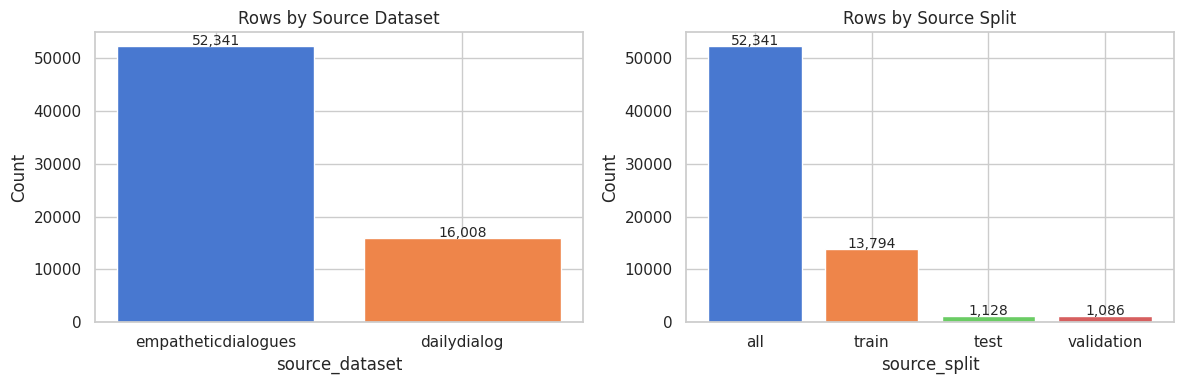

     source_dataset source_split  count
        dailydialog         test   1128
        dailydialog        train  13794
        dailydialog   validation   1086
empatheticdialogues          all  52341


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Source dataset
src_counts = df["source_dataset"].value_counts()
axes[0].bar(src_counts.index, src_counts.values, color=sns.color_palette("muted", len(src_counts)))
for i, v in enumerate(src_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
axes[0].set_title("Rows by Source Dataset")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("source_dataset")

# Split
split_counts = df["source_split"].value_counts()
axes[1].bar(split_counts.index, split_counts.values, color=sns.color_palette("muted", len(split_counts)))
for i, v in enumerate(split_counts.values):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
axes[1].set_title("Rows by Source Split")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("source_split")

plt.tight_layout()
plt.show()

print(df.groupby(["source_dataset", "source_split"]).size().reset_index(name="count").to_string(index=False))

## 5. Intensity Level Distribution

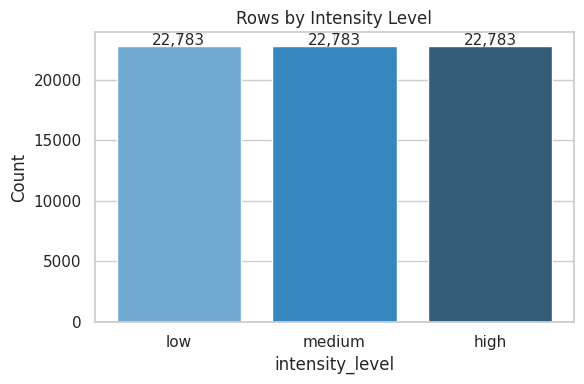

intensity_level       high    low  medium    All
source_dataset                                  
dailydialog           5336   5336    5336  16008
empatheticdialogues  17447  17447   17447  52341
All                  22783  22783   22783  68349


In [17]:
intensity_order = ["low", "medium", "high"]
intensity_counts = df["intensity_level"].value_counts().reindex(intensity_order)

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Blues_d", 3)
ax.bar(intensity_counts.index, intensity_counts.values, color=palette)
for i, v in enumerate(intensity_counts.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=11)
ax.set_title("Rows by Intensity Level")
ax.set_ylabel("Count")
ax.set_xlabel("intensity_level")
plt.tight_layout()
plt.show()

# Cross-tab: source × intensity
print(pd.crosstab(df["source_dataset"], df["intensity_level"], margins=True))

## 6. Meaning-Preservation Score Distribution

count    68349.000000
mean         0.943238
std          0.020740
min          0.400000
25%          0.950000
50%          0.950000
75%          0.950000
max          1.000000
Name: meaning_preserved_score, dtype: float64


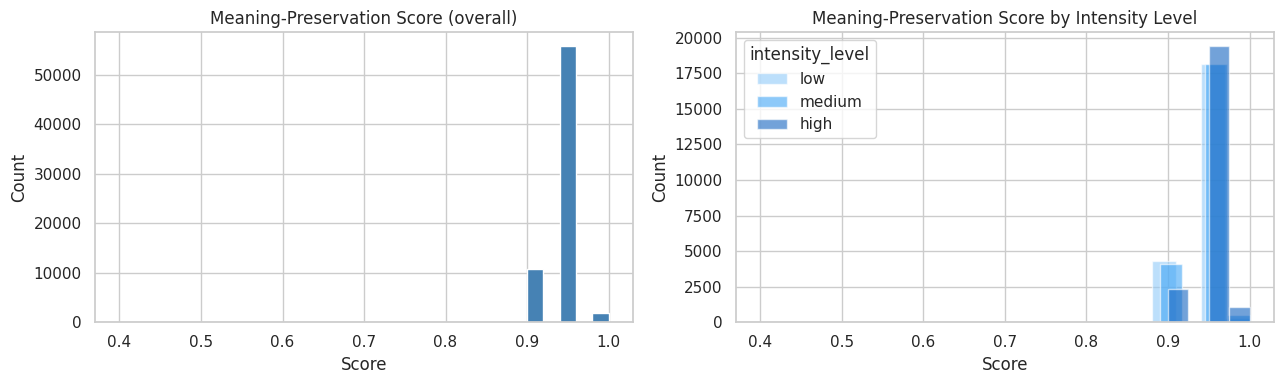

                   count      mean       std   min   25%   50%   75%  max
intensity_level                                                          
low              22783.0  0.941020  0.021897  0.40  0.95  0.95  0.95  1.0
medium           22783.0  0.941969  0.021231  0.45  0.95  0.95  0.95  1.0
high             22783.0  0.946725  0.018482  0.50  0.95  0.95  0.95  1.0


In [18]:
print(df["meaning_preserved_score"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall histogram
axes[0].hist(df["meaning_preserved_score"], bins=30, edgecolor="white", color="steelblue")
axes[0].set_title("Meaning-Preservation Score (overall)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

# By intensity level
for level, color in zip(intensity_order, ["#90caf9", "#42a5f5", "#1565c0"]):
    subset = df[df["intensity_level"] == level]["meaning_preserved_score"]
    axes[1].hist(subset, bins=20, alpha=0.6, label=level, color=color, edgecolor="white")
axes[1].set_title("Meaning-Preservation Score by Intensity Level")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")
axes[1].legend(title="intensity_level")

plt.tight_layout()
plt.show()

print(df.groupby("intensity_level")["meaning_preserved_score"].describe().loc[intensity_order])

## 7. Rewrite Length Analysis

In [19]:
# Word count helper
def word_count(s):
    return len(str(s).split())

df["base_len"] = df["base_text"].apply(word_count)
for col, label in zip(EMOTION_COLS, EMOTION_LABELS):
    df[f"{label}_len"] = df[col].apply(word_count)

len_cols = ["base_len"] + [f"{e}_len" for e in EMOTION_LABELS]
len_stats = df[len_cols].describe().T
print(len_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]].to_string())

                       mean        std  min   25%   50%   75%   max
base_len          25.376860  16.789879  5.0  14.0  19.0  31.0  81.0
joy_len           20.614318   6.975276  5.0  16.0  19.0  23.0  92.0
trust_len         20.702366   6.806328  6.0  17.0  19.0  23.0  83.0
fear_len          21.187508   7.185175  5.0  17.0  20.0  23.0  95.0
surprise_len      19.156637   6.682958  1.0  15.0  18.0  21.0  80.0
sadness_len       20.619424   7.001305  6.0  16.0  19.0  23.0  89.0
disgust_len       20.218233   6.781259  6.0  16.0  19.0  23.0  84.0
anger_len         20.476774   6.727562  4.0  16.0  19.0  23.0  88.0
anticipation_len  20.968924   6.744853  5.0  17.0  20.0  23.0  89.0


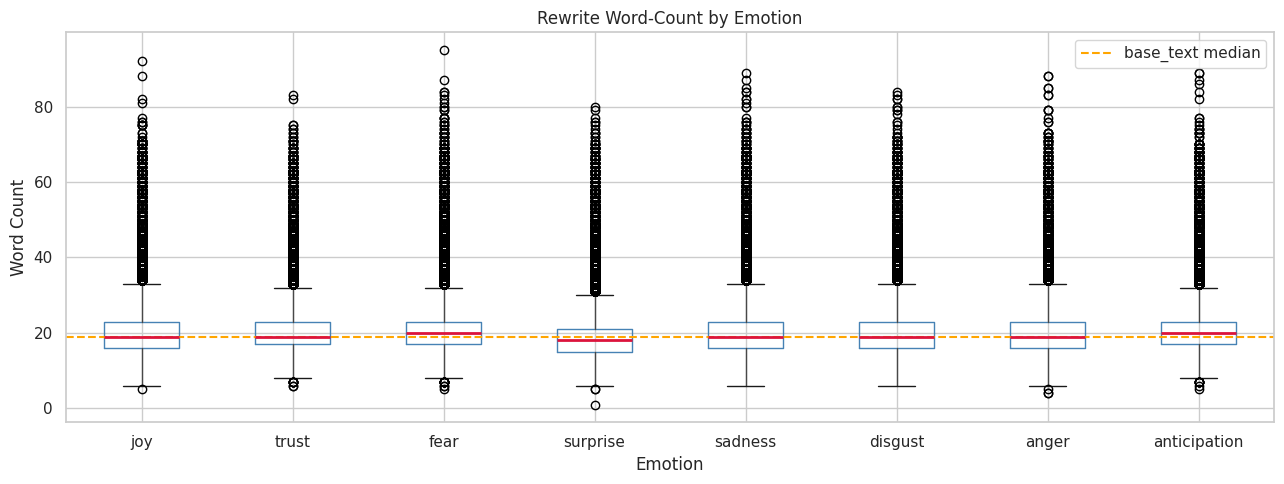

In [20]:
# Boxplot: rewrite lengths per emotion
rewrite_len_data = pd.DataFrame(
    {label: df[f"{label}_len"] for label in EMOTION_LABELS}
)

fig, ax = plt.subplots(figsize=(13, 5))
rewrite_len_data.boxplot(ax=ax, notch=False, vert=True,
                         boxprops=dict(color="steelblue"),
                         medianprops=dict(color="crimson", linewidth=2))
ax.axhline(df["base_len"].median(), color="orange", linestyle="--", label="base_text median")
ax.set_title("Rewrite Word-Count by Emotion")
ax.set_ylabel("Word Count")
ax.set_xlabel("Emotion")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Length Delta: Rewrite vs Base Text

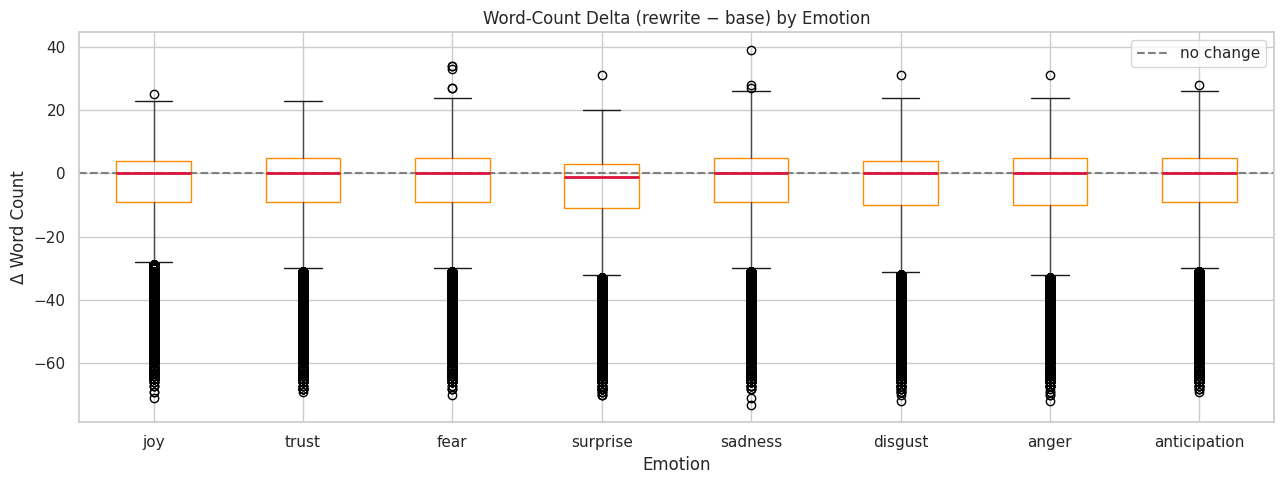

                  mean        std  median
joy          -4.762542  14.087338     0.0
trust        -4.674494  14.401148     0.0
fear         -4.189352  14.348574     0.0
surprise     -6.220223  14.430625    -1.0
sadness      -4.757436  14.440068     0.0
disgust      -5.158627  14.672627     0.0
anger        -4.900086  14.637692     0.0
anticipation -4.407936  14.659041     0.0


In [21]:
delta_data = {}
for label in EMOTION_LABELS:
    delta_data[label] = df[f"{label}_len"] - df["base_len"]

delta_df = pd.DataFrame(delta_data)

fig, ax = plt.subplots(figsize=(13, 5))
delta_df.boxplot(ax=ax, notch=False, vert=True,
                 boxprops=dict(color="darkorange"),
                 medianprops=dict(color="crimson", linewidth=2))
ax.axhline(0, color="gray", linestyle="--", label="no change")
ax.set_title("Word-Count Delta (rewrite − base) by Emotion")
ax.set_ylabel("Δ Word Count")
ax.set_xlabel("Emotion")
ax.legend()
plt.tight_layout()
plt.show()

print(delta_df.describe().T[["mean", "std", "50%"]].rename(columns={"50%": "median"}).to_string())

## 9. Vocabulary Diversity per Emotion (Type-Token Ratio)

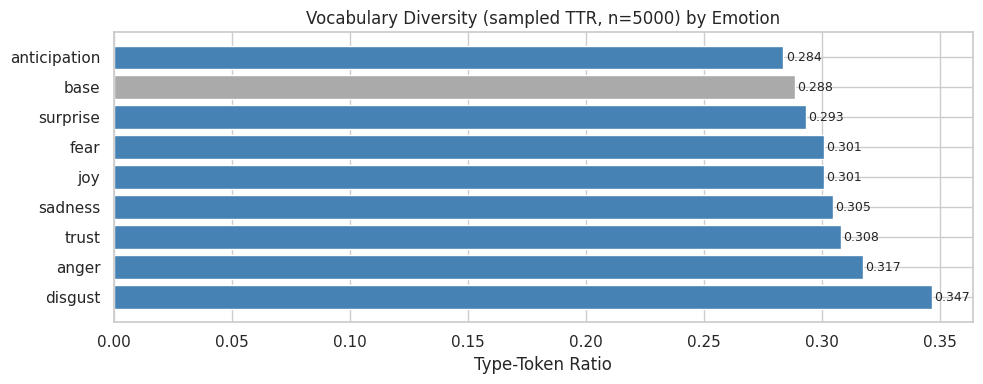

In [22]:
def ttr(series: pd.Series, sample_size: int = 5000) -> float:
    """Type-Token Ratio on a random sample of tokens to normalise for corpus size."""
    all_tokens = " ".join(series.dropna().str.lower()).split()
    rng = np.random.default_rng(42)
    sample = rng.choice(all_tokens, size=min(sample_size, len(all_tokens)), replace=False)
    return len(set(sample)) / len(sample)

ttr_results = {"base": ttr(df["base_text"])}
for col, label in zip(EMOTION_COLS, EMOTION_LABELS):
    ttr_results[label] = ttr(df[col])

ttr_series = pd.Series(ttr_results).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#aaaaaa" if k == "base" else "steelblue" for k in ttr_series.index]
ax.barh(ttr_series.index, ttr_series.values, color=colors)
ax.set_title("Vocabulary Diversity (sampled TTR, n=5000) by Emotion")
ax.set_xlabel("Type-Token Ratio")
for i, (k, v) in enumerate(ttr_series.items()):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 10. Rewrite Similarity to Base (Character-Level Jaccard)

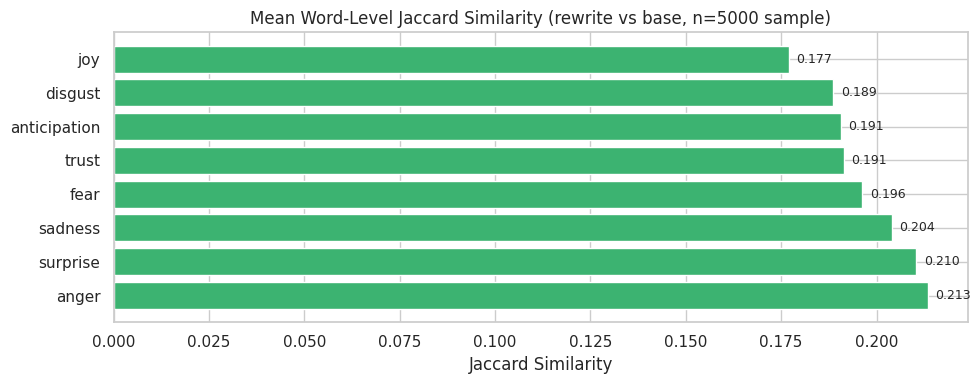

In [23]:
def word_jaccard(a: str, b: str) -> float:
    sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)

# Compute on a random sample to keep it fast
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

jaccard_means = {}
for col, label in zip(EMOTION_COLS, EMOTION_LABELS):
    scores = sample_df.apply(lambda r: word_jaccard(r["base_text"], r[col]), axis=1)
    jaccard_means[label] = scores.mean()

jac_series = pd.Series(jaccard_means).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(jac_series.index, jac_series.values, color="mediumseagreen")
ax.set_title("Mean Word-Level Jaccard Similarity (rewrite vs base, n=5000 sample)")
ax.set_xlabel("Jaccard Similarity")
for i, (k, v) in enumerate(jac_series.items()):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Meaning-Preservation Score vs Intensity (Violin)

/tmp/ipykernel_13456/3578762483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


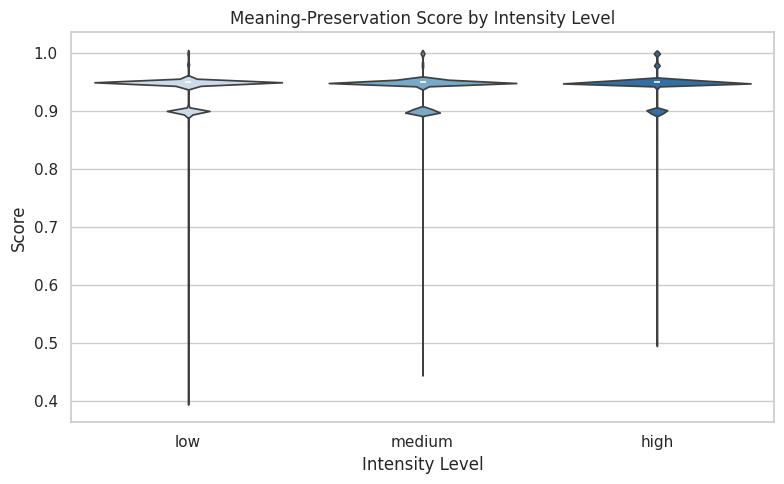

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="intensity_level",
    y="meaning_preserved_score",
    order=intensity_order,
    palette="Blues",
    inner="box",
    ax=ax,
)
ax.set_title("Meaning-Preservation Score by Intensity Level")
ax.set_xlabel("Intensity Level")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 12. Sample Rows per Emotion × Intensity

In [25]:
pd.set_option("display.max_colwidth", 120)

sample_row = df[(df["intensity_level"] == "high") & (df["source_dataset"] == "dailydialog")].sample(1, random_state=0).iloc[0]

print("=== Base text ===")
print(sample_row["base_text"])
print()
for col, label in zip(EMOTION_COLS, EMOTION_LABELS):
    print(f"[{label.upper()}]")
    print(sample_row[col])
    print()

=== Base text ===
Hey , Trev ! How did the shopping go ?  “ You ain't nothing ' but a hound-dog ... ”  Trev , are you OK ?  Of course I'm OK ! I just bought a bunch of classic Elvis records !  Aren't you lucky . The vintage-clock guy is driving a hard bargain . So I have nothing .  No sweat . Just go back and talk him down . Here comes Wei .

[JOY]
Hey, Trev! How did the shopping go? "You ain't nothing but a hound-dog..." Trev, are you OK? Of course I’m thrilled! I just scored a great pile of classic Elvis records! Aren't you lucky? The vintage-clock guy was tough, but I managed to get some deals. No worries—I’m ready to try again. Here comes Wei!

[TRUST]
Hey, Trev! How did the shopping go? "You ain't nothing but a hound-dog..." Trev, are you OK? Absolutely, I’m confident about my choices—I got a solid collection of classic Elvis records. The vintage-clock guy is firm on price, but I trust I can negotiate again. I'll just head back and see what I can do. Here comes Wei.

[FEAR]
Hey, T